In [67]:
import os
import re
import numpy as np
import pandas as pd
import shutil
import random
import json
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image

In [69]:
def parse_label(label_name):
    raw = os.path.splitext(str(label_name).strip())[0].lower()
    raw = raw.replace('-', '_').replace(' ', '_')

    if '___' in raw:
        crop, disease = raw.split('___', 1)
    elif '__' in raw:
        crop, disease = raw.split('__', 1)
    elif '_' in raw:
        crop, disease = raw.split('_', 1)
    else:
        crop, disease = raw, 'healthy'

    crop = re.sub(r'_+', '_', crop).strip('_')
    disease = re.sub(r'_+', '_', disease).strip('_') or 'healthy'
    return crop, disease


def class_name_to_crop(class_name):
    return parse_label(class_name)[0]


def class_name_to_disease(class_name):
    return parse_label(class_name)[1]

In [70]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")
path = path + "/PlantVillage"
print("Path to dataset files:", path)


Path to dataset files: C:\Users\enapa\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1/PlantVillage


In [71]:
#Dataset structure
#Folder structure:
# --- IGNORE ---
#dataset/
# CropName1_disease/
# CropName2_disease/

In [72]:
print("Dataset folder structure:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")

Dataset folder structure:
PlantVillage/
    Pepper__bell___Bacterial_spot/
    Pepper__bell___healthy/
    PlantVillage/
        Pepper__bell___Bacterial_spot/
        Pepper__bell___healthy/
        Potato___Early_blight/
        Potato___healthy/
        Potato___Late_blight/
        Tomato_Bacterial_spot/
        Tomato_Early_blight/
        Tomato_healthy/
        Tomato_Late_blight/
        Tomato_Leaf_Mold/
        Tomato_Septoria_leaf_spot/
        Tomato_Spider_mites_Two_spotted_spider_mite/
        Tomato__Target_Spot/
        Tomato__Tomato_mosaic_virus/
        Tomato__Tomato_YellowLeaf__Curl_Virus/
    Potato___Early_blight/
    Potato___healthy/
    Potato___Late_blight/
    Tomato_Bacterial_spot/
    Tomato_Early_blight/
    Tomato_healthy/
    Tomato_Late_blight/
    Tomato_Leaf_Mold/
    Tomato_Septoria_leaf_spot/
    Tomato_Spider_mites_Two_spotted_spider_mite/
    Tomato__Target_Spot/
    Tomato__Tomato_mosaic_virus/
    Tomato__Tomato_YellowLeaf__Curl_Virus/


In [73]:
# Using the folder structure to split into train, test, and validation
# Each class folder is expected to encode the crop and disease name.
FINAL_DIR = "final_dataset"
DATA_DIR = path
OUTPUT_DIR = "output_dataset"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SKIP_FOLDERS = {"train", "val", "valid", "validation", "test", "images", "image", "img"}
SPLITS = (0.7, 0.15, 0.15)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [74]:
# Split dataset into train/val/test using class folders: Crop_Disease
source_dir = DATA_DIR
assert os.path.isdir(source_dir), f"Source directory not found: {source_dir}"

# Fresh output directories
for target_dir in [OUTPUT_DIR, FINAL_DIR]:
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)
    os.makedirs(target_dir, exist_ok=True)

split_names = ("train", "val", "test")
for s in split_names:
    os.makedirs(os.path.join(OUTPUT_DIR, s), exist_ok=True)

valid_ext = {ext.lower() for ext in IMAGE_EXTENSIONS}
counts = {}

class_folders = [
    d for d in os.listdir(source_dir)
    if os.path.isdir(os.path.join(source_dir, d)) and d.lower() not in SKIP_FOLDERS
]

for class_name in sorted(class_folders):
    class_path = os.path.join(source_dir, class_name)
    crop, disease = parse_label(class_name)

    images = [
        f for f in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, f))
        and os.path.splitext(f)[1].lower() in valid_ext
    ]
    if not images:
        continue

    random.shuffle(images)
    n = len(images)
    n_train = int(n * SPLITS[0])
    n_val = int(n * SPLITS[1])
    n_test = n - n_train - n_val

    splits = {
        "train": images[:n_train],
        "val": images[n_train:n_train + n_val],
        "test": images[n_train + n_val:]
    }

    counts[class_name] = {
        "crop": crop,
        "disease": disease,
        "train": n_train,
        "val": n_val,
        "test": n_test,
        "total": n
    }

    for split_name, file_list in splits.items():
        global_dst = os.path.join(OUTPUT_DIR, split_name, class_name)
        crop_dst = os.path.join(FINAL_DIR, crop, split_name, disease)
        os.makedirs(global_dst, exist_ok=True)
        os.makedirs(crop_dst, exist_ok=True)

        for fname in file_list:
            src = os.path.join(class_path, fname)
            shutil.copy2(src, os.path.join(global_dst, fname))
            shutil.copy2(src, os.path.join(crop_dst, fname))

# Summary dataframe
df = pd.DataFrame(
    [{"class": cls, **v} for cls, v in counts.items()]
).sort_values("class").reset_index(drop=True)

print(f"Done. Dataset split saved to: {OUTPUT_DIR}")
print(df.head())
print(f"Classes: {len(df)}, Total images: {int(df['total'].sum()) if not df.empty else 0}")

Done. Dataset split saved to: output_dataset
                           class         crop         disease  train  val  \
0  Pepper__bell___Bacterial_spot  pepper_bell  bacterial_spot    697  149   
1         Pepper__bell___healthy  pepper_bell         healthy   1034  221   
2          Potato___Early_blight       potato    early_blight    700  150   
3           Potato___Late_blight       potato     late_blight    700  150   
4               Potato___healthy       potato         healthy    106   22   

   test  total  
0   151    997  
1   223   1478  
2   150   1000  
3   150   1000  
4    24    152  
Classes: 15, Total images: 20638


In [75]:
# Plotting based on the crop name and disease name separately
def plot_crop_disease_distribution(base_dir):
    crop_counts = {}
    disease_counts = {}

    for split in ["train", "val", "test"]:
        split_dir = os.path.join(base_dir, split)
        for class_name in os.listdir(split_dir):
            class_path = os.path.join(split_dir, class_name)
            if os.path.isdir(class_path):
                count = len(os.listdir(class_path))
                crop, disease = parse_label(class_name)
                crop_counts[crop] = crop_counts.get(crop, 0) + count
                disease_counts[disease] = disease_counts.get(disease, 0) + count

    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(crop_counts.keys()), y=list(crop_counts.values()))
    plt.xticks(rotation=90)
    plt.title("Crop Distribution")
    plt.xlabel("Crop")
    plt.ylabel("Number of Images")
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(disease_counts.keys()), y=list(disease_counts.values()))
    plt.xticks(rotation=90)
    plt.title("Disease Distribution")
    plt.xlabel("Disease")
    plt.ylabel("Number of Images")
    plt.show()

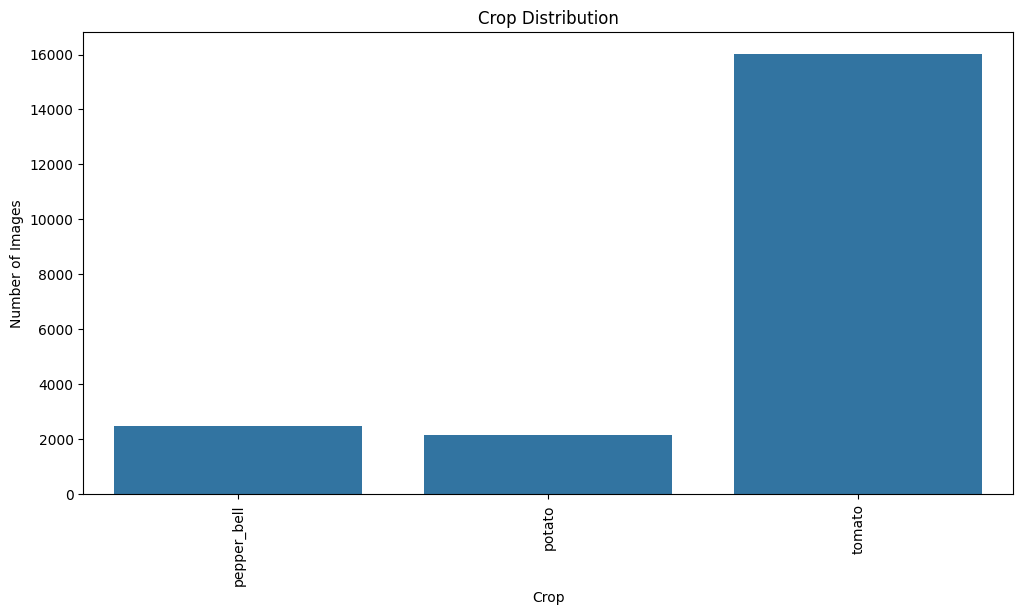

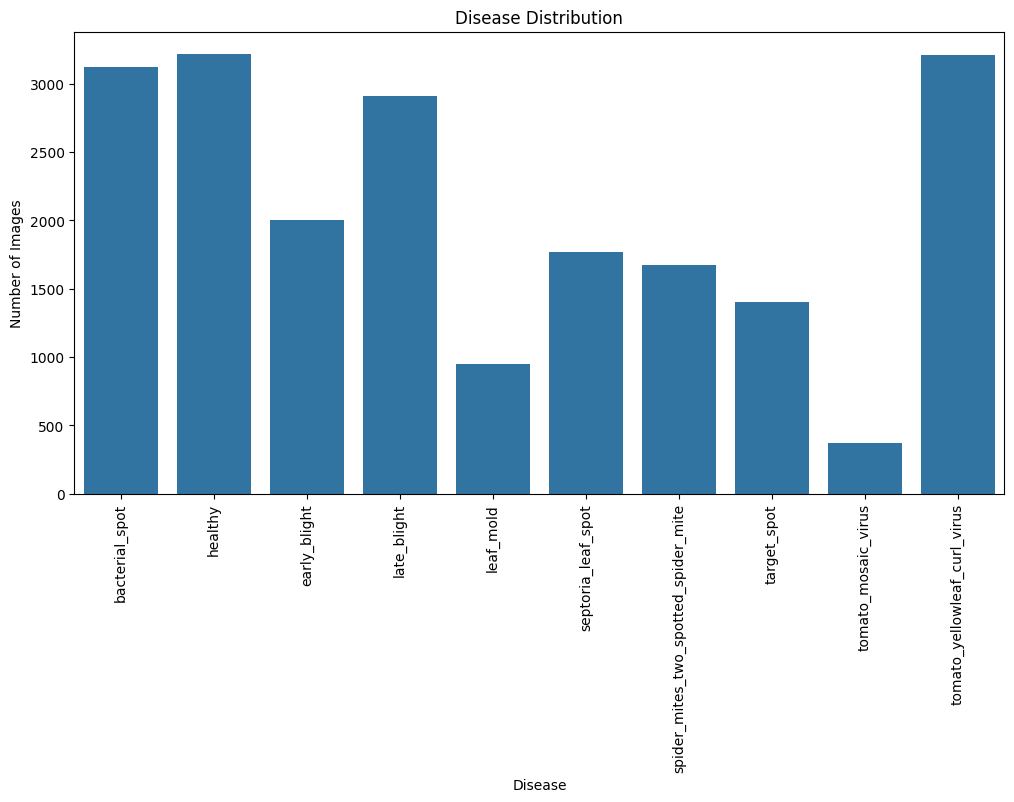

In [76]:
plot_crop_disease_distribution(OUTPUT_DIR)

In [78]:
# Visualize crop image samples
def plot_sample_images(base_dir, num_samples=5):
    class_names = sorted(os.listdir(os.path.join(base_dir, "train")))
    plt.figure(figsize=(15, 10))
    for i, class_name in enumerate(class_names[:num_samples]):
        class_path = os.path.join(base_dir, "train", class_name)
        if os.path.isdir(class_path):
            sample_images = random.sample(os.listdir(class_path), min(num_samples, len(os.listdir(class_path))))
            for j, img_name in enumerate(sample_images):
                img_path = os.path.join(class_path, img_name)
                img = image.load_img(img_path, target_size=IMG_SIZE)
                plt.subplot(num_samples, num_samples, i * num_samples + j + 1)
                plt.imshow(img)
                plt.title(class_name)
                plt.axis("off")
    plt.tight_layout()
    plt.show()

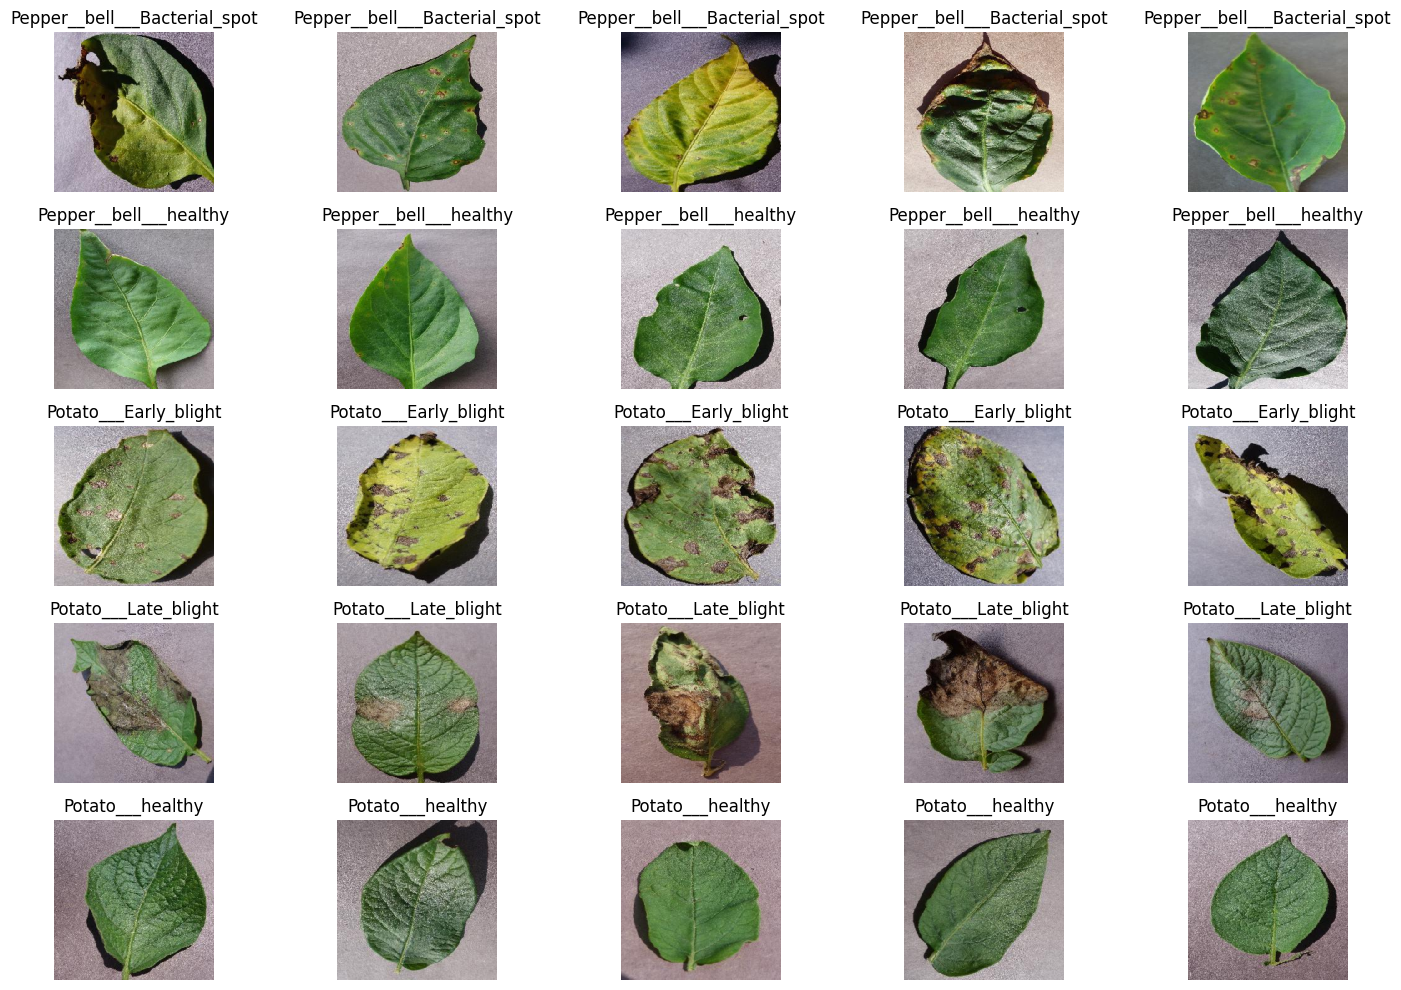

In [80]:
plot_sample_images(OUTPUT_DIR)

In [109]:
# Rebuild datasets so preprocessing is consistent across train/val/test
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(OUTPUT_DIR, "train"),
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=42
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(OUTPUT_DIR, "val"),
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(OUTPUT_DIR, "test"),
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False
)

class_names = list(train_ds.class_names)

Found 14440 files belonging to 15 classes.
Found 3089 files belonging to 15 classes.
Found 3109 files belonging to 15 classes.


In [110]:
num_classes = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE

# Augmentation for train only
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [111]:
def preprocess(x, y):
    x = tf.keras.applications.mobilenet_v2.preprocess_input(tf.cast(x, tf.float32))
    return x, y

train_ds = train_ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Build transfer learning model
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [112]:
# Training loop: head training
EPOCHS_HEAD = 5
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    verbose=1,
    )
model_training_history = history_head.history

Epoch 1/5


452/452 ━━━━━━━━━━━━━━━━━━━━ 165s 347ms/step - accuracy: 0.7226 - loss: 0.9003 - val_accuracy: 0.8462 - val_loss: 0.4867
Epoch 2/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 178s 394ms/step - accuracy: 0.8506 - loss: 0.4720 - val_accuracy: 0.8799 - val_loss: 0.3838
Epoch 3/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 172s 379ms/step - accuracy: 0.8677 - loss: 0.4090 - val_accuracy: 0.8883 - val_loss: 0.3483
Epoch 4/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 162s 357ms/step - accuracy: 0.8831 - loss: 0.3616 - val_accuracy: 0.8925 - val_loss: 0.3265
Epoch 5/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 188s 415ms/step - accuracy: 0.8872 - loss: 0.3467 - val_accuracy: 0.8903 - val_loss: 0.3341


In [114]:
# Fine-tuning: unfreeze top layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS_FT = 5
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD + EPOCHS_FT,
    initial_epoch=EPOCHS_HEAD,
    verbose=1,
    )
ft_history = history_ft.history

Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 263s 558ms/step - accuracy: 0.7749 - loss: 0.7929 - val_accuracy: 0.9045 - val_loss: 0.2850
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 199s 439ms/step - accuracy: 0.8706 - loss: 0.3805 - val_accuracy: 0.9132 - val_loss: 0.2745
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 216s 477ms/step - accuracy: 0.8939 - loss: 0.3155 - val_accuracy: 0.9077 - val_loss: 0.2643
Epoch 9/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 261s 576ms/step - accuracy: 0.9077 - loss: 0.2766 - val_accuracy: 0.9191 - val_loss: 0.2347
Epoch 10/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 263s 577ms/step - accuracy: 0.9184 - loss: 0.2425 - val_accuracy: 0.9268 - val_loss: 0.2166


In [116]:
# Plot training history
def _pick_metric(history, candidates):
    for key in candidates:
        if key in history and len(history.get(key, [])) > 0:
            return history[key]
    return []

def plot_training_history(history, title):
    if not history or not isinstance(history, dict):
        print(f"No history available for {title}.")
        return None

    train_acc = _pick_metric(history, ["accuracy", "acc", "categorical_accuracy", "sparse_categorical_accuracy"])
    val_acc = _pick_metric(history, ["val_accuracy", "val_acc", "val_categorical_accuracy", "val_sparse_categorical_accuracy"])
    train_loss = history.get("loss", [])
    val_loss = history.get("val_loss", [])

    if len(train_acc) == 0 and len(train_loss) == 0:
        print(f"History for {title} has no plottable values. Keys: {list(history.keys())}")
        return None

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    if len(train_acc) > 0:
        axes[0].plot(train_acc, marker="o", label="Train Acc")
    if len(val_acc) > 0:
        axes[0].plot(val_acc, marker="o", label="Val Acc")
    axes[0].set_title(f"{title} Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    if len(train_acc) > 0 or len(val_acc) > 0:
        axes[0].legend()

    if len(train_loss) > 0:
        axes[1].plot(train_loss, marker="o", label="Train Loss")
    if len(val_loss) > 0:
        axes[1].plot(val_loss, marker="o", label="Val Loss")
    axes[1].set_title(f"{title} Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    if len(train_loss) > 0 or len(val_loss) > 0:
        axes[1].legend()

    plt.tight_layout()
    plt.show()
    return fig

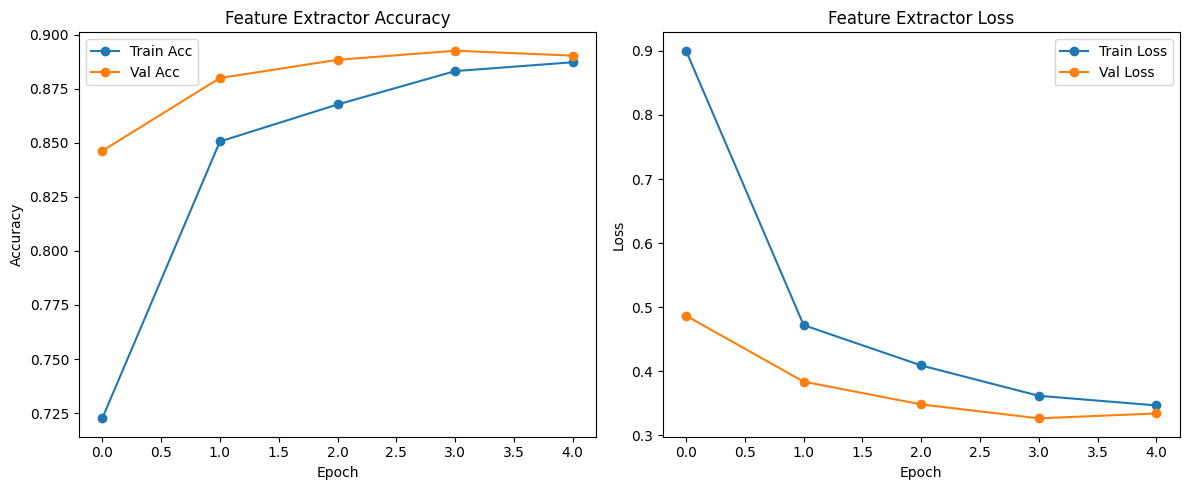

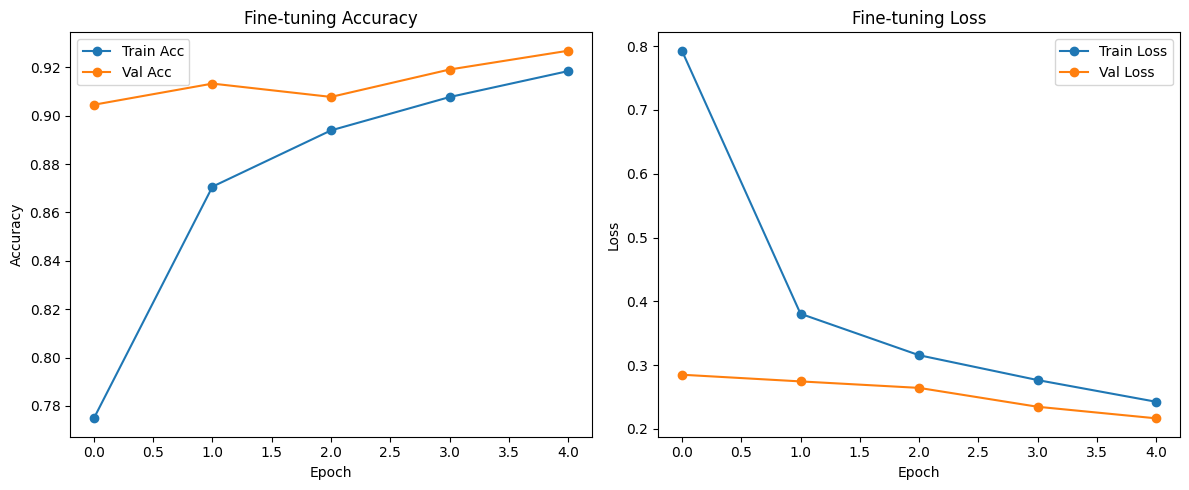

(<Figure size 1200x500 with 2 Axes>, <Figure size 1200x500 with 2 Axes>)

In [115]:
fig1 = plot_training_history(model_training_history, "Feature Extractor")
fig2 = plot_training_history(ft_history, "Fine-tuning")
fig1, fig2

In [117]:
# Final test evaluation
test_losses = []
test_accuracies = []

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

#Store stats for plotting
test_losses.append(test_loss)
test_accuracies.append(test_acc)

98/98 ━━━━━━━━━━━━━━━━━━━━ 30s 303ms/step - accuracy: 0.9299 - loss: 0.2206
Test loss: 0.2206
Test accuracy: 0.9299


In [94]:
#Try predicting on a few test samples
def predict_samples(model, dataset, class_names, num_samples=5):
    for images, labels in dataset.take(1):
        for i in range(num_samples):
            img = images[i]
            true_label = class_names[tf.argmax(labels[i])]
            img_expanded = tf.expand_dims(img, axis=0)
            predictions = model.predict(img_expanded)
            predicted_label = class_names[tf.argmax(predictions[0])]
            
            plt.imshow((img + 1) / 2)  # De-normalize for visualization
            plt.title(f"True: {true_label}\nPredicted: {predicted_label}")
            plt.axis('off')
            plt.show()

In [100]:
# Crop-aware single-image prediction with low-confidence feedback capture
class_to_idx = {name: i for i, name in enumerate(class_names)}
class_meta = {name: parse_label(name) for name in class_names}
CONFIDENCE_THRESHOLD = 0.6
hitl_feedback = []


def predict_disease_for_crop(crop_name, img_path, model=model, class_names=class_names, threshold=CONFIDENCE_THRESHOLD):
    crop_name = str(crop_name).strip().lower()

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)[0]
    candidate_indices = [
        i for i, class_name in enumerate(class_names)
        if class_meta[class_name][0] == crop_name
    ]

    if candidate_indices:
        crop_probs = preds[candidate_indices]
        best_local_idx = int(np.argmax(crop_probs))
        best_idx = candidate_indices[best_local_idx]
        confidence = float(crop_probs[best_local_idx] / crop_probs.sum()) if float(crop_probs.sum()) > 0 else float(preds[best_idx])
    else:
        best_idx = int(np.argmax(preds))
        confidence = float(preds[best_idx])

    class_name = class_names[best_idx]
    predicted_crop, predicted_disease = class_meta[class_name]

    result = {
        "crop": predicted_crop,
        "predicted_disease": predicted_disease,
        "class_name": class_name,
        "confidence": confidence,
        "status": "confirmed" if confidence >= threshold else "review"
    }

    print(f"Crop: {predicted_crop}")
    print(f"Predicted disease: {predicted_disease}")
    print(f"Confidence: {confidence:.2%}")

    if confidence < threshold:
        corrected_disease = input("Low confidence. Enter the correct disease name: ").strip().lower()
        if corrected_disease:
            hitl_feedback.append({
                "image_path": img_path,
                "input_crop": crop_name,
                "predicted_class": class_name,
                "predicted_disease": predicted_disease,
                "confidence": confidence,
                "corrected_disease": corrected_disease,
            })
            with open("hitl_feedback.json", "w") as f:
                json.dump(hitl_feedback, f, indent=2)
            result["corrected_disease"] = corrected_disease

    return result


# Example:
# prediction = predict_disease_for_crop("tomato", "sample.jpg")
# print(prediction)

In [101]:
# Example interactive usage for a crop-specific prediction flow
crop_name = input("Enter crop type: ").strip()
img_path = input("Enter image path: ").strip()
prediction = predict_disease_for_crop(crop_name, img_path)
print(prediction)

Crop: tomato
Predicted disease: healthy
Confidence: 100.00%
{'crop': 'tomato', 'predicted_disease': 'healthy', 'class_name': 'Tomato_healthy', 'confidence': 0.9999634623527527, 'status': 'confirmed'}


In [103]:
model.save("models/crop_model.keras")

import json
with open("models/class_names.json", "w") as f:
    json.dump(class_names, f)

In [108]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

OPTIMIZED_DIR = Path("models/optimized")
OPTIMIZED_DIR.mkdir(parents=True, exist_ok=True)
TEST_DIR = Path(OUTPUT_DIR) / "test"


def file_size_mb(path):
    path = Path(path)
    return round(path.stat().st_size / (1024 * 1024), 3) if path.exists() else None


def build_test_dataset(batch_size=1):
    return tf.keras.preprocessing.image_dataset_from_directory(
        TEST_DIR,
        labels="inferred",
        label_mode="categorical",
        batch_size=batch_size,
        image_size=IMG_SIZE,
        shuffle=False,
    )


def preprocess_for_mobilenet(dataset):
    return dataset.map(
        lambda x, y: (tf.keras.applications.mobilenet_v2.preprocess_input(tf.cast(x, tf.float32)), y),
        num_parallel_calls=AUTOTUNE,
    ).prefetch(AUTOTUNE)


def estimate_flops(keras_model, sample_input):
    try:
        from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

        concrete_fn = tf.function(lambda x: keras_model(x, training=False)).get_concrete_function(
            tf.TensorSpec(sample_input.shape, tf.float32)
        )
        _, graph_def = convert_variables_to_constants_v2_as_graph(concrete_fn)

        with tf.Graph().as_default() as graph:
            tf.import_graph_def(graph_def, name="")
            run_meta = tf.compat.v1.RunMetadata()
            options = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
            profile = tf.compat.v1.profiler.profile(
                graph=graph,
                run_meta=run_meta,
                cmd="op",
                options=options,
            )
        return int(profile.total_float_ops) if profile is not None else None
    except Exception as exc:
        print(f"FLOPs estimation skipped: {exc}")
        return None


def benchmark_keras(keras_model, sample_input, runs=20):
    for _ in range(3):
        _ = keras_model(sample_input, training=False)

    timings = []
    for _ in range(runs):
        start = time.perf_counter()
        _ = keras_model(sample_input, training=False)
        timings.append((time.perf_counter() - start) * 1000)

    return float(np.mean(timings)), float(np.std(timings))


def export_tflite_dynamic_range(keras_model, export_path):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    export_path = Path(export_path)
    export_path.write_bytes(tflite_model)
    return export_path


def benchmark_tflite(tflite_path, sample_input, runs=20):
    interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    input_index = input_details[0]["index"]
    sample_np = sample_input.numpy().astype(input_details[0]["dtype"], copy=False)

    for _ in range(3):
        interpreter.set_tensor(input_index, sample_np)
        interpreter.invoke()

    timings = []
    for _ in range(runs):
        start = time.perf_counter()
        interpreter.set_tensor(input_index, sample_np)
        interpreter.invoke()
        timings.append((time.perf_counter() - start) * 1000)

    return float(np.mean(timings)), float(np.std(timings))


def evaluate_keras_accuracy_on_testset(keras_model, dataset):
    correct = 0
    total = 0

    for images, labels in dataset:
        predictions = keras_model(images, training=False).numpy()
        correct += int(np.sum(np.argmax(predictions, axis=1) == np.argmax(labels.numpy(), axis=1)))
        total += int(labels.shape[0])

    return correct / total if total else float("nan")


def evaluate_tflite_accuracy_on_testset(tflite_path, dataset):
    interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    input_index = input_details[0]["index"]
    output_index = output_details[0]["index"]
    input_dtype = input_details[0]["dtype"]

    correct = 0
    total = 0

    for images, labels in dataset:
        images_np = images.numpy().astype(input_dtype, copy=False)
        labels_np = labels.numpy()

        for image_np, label_np in zip(images_np, labels_np):
            interpreter.set_tensor(input_index, np.expand_dims(image_np, axis=0))
            interpreter.invoke()
            predictions = interpreter.get_tensor(output_index)
            correct += int(np.argmax(predictions[0]) == np.argmax(label_np))
            total += 1

    return correct / total if total else float("nan")


test_eval_ds = preprocess_for_mobilenet(build_test_dataset(batch_size=1))
sample_batch = next(iter(test_eval_ds.take(1)))[0]
sample_batch = tf.cast(sample_batch, tf.float32)

baseline_keras_path = Path("models/crop_model.keras")
tflite_path = OPTIMIZED_DIR / "crop_model_dynamic_range.tflite"

baseline_accuracy = evaluate_keras_accuracy_on_testset(model, test_eval_ds)
baseline_latency = benchmark_keras(model, sample_batch)
baseline_flops = estimate_flops(model, sample_batch)
baseline_params = model.count_params()

tflite_exported = export_tflite_dynamic_range(model, tflite_path)
tflite_accuracy = evaluate_tflite_accuracy_on_testset(tflite_exported, test_eval_ds)
tflite_latency = benchmark_tflite(tflite_exported, sample_batch)

comparison_df = pd.DataFrame(
    [
        {
            "format": "Keras FP32",
            "artifact": str(baseline_keras_path),
            "size_mb": file_size_mb(baseline_keras_path),
            "params": baseline_params,
            "flops": baseline_flops,
            "accuracy": baseline_accuracy,
            "latency_ms": baseline_latency[0],
        },
        {
            "format": "TFLite dynamic range",
            "artifact": str(tflite_exported),
            "size_mb": file_size_mb(tflite_exported),
            "params": baseline_params,
            "flops": baseline_flops,
            "accuracy": tflite_accuracy,
            "latency_ms": tflite_latency[0],
        },
    ]
)

comparison_df


Found 3109 files belonging to 15 classes.
INFO:tensorflow:Assets written to: C:\Users\enapa\AppData\Local\Temp\tmpsjyi6h_n\assets


INFO:tensorflow:Assets written to: C:\Users\enapa\AppData\Local\Temp\tmpsjyi6h_n\assets


Saved artifact at 'C:\Users\enapa\AppData\Local\Temp\tmpsjyi6h_n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_321')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  2158169422352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2158169625360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2158169625552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2158169624016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2158169627664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2158169625936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2158169621136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2158169620944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2158169628048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2158169626128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

c:\Users\enapa\anaconda3\envs\ml\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,format,artifact,size_mb,params,flops,accuracy,latency_ms
0,Keras FP32,models\crop_model.keras,21.062,2277199,612764698,0.927629,132.364125
1,TFLite dynamic range,models\optimized\crop_model_dynamic_range.tflite,2.409,2277199,612764698,0.925378,45.117415
